In [3]:
import os
import pandas as pd
import numpy as np

In [4]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_size = {
    "mmlu": 116000,
    "squadv2": 130000,
    "truthful_qa": 817
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuAD2.0",
    "truthful_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [5]:
prompt_type = "hedged_qa"

In [6]:
results_dir = f"/hdd/ivny/{prompt_type}_in_domain_calibration"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

all_records = []
for leaf_dir in leaf_dirs:
    _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
    if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
        csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
        csv_records = csv_data.transpose().to_dict("records")

        for record in csv_records:
            record["dataset"] = dataset_map.get(dataset_name, dataset_name)
            record["model"] = model_name_map.get(model_name, model_name)
            record["dataset_size"] = dataset_size.get(dataset_name, None)

        all_records.extend(csv_records)
    else:
        print(model_name, dataset_name, "missing calibration_performance.csv")

In [7]:
# mean_df = pd.DataFrame(all_records).drop(columns=["dataset"]).groupby(["model"]).mean().reset_index()
# mean_df

df = pd.DataFrame(all_records).drop(columns=["dataset"])

group_cols = ["model"]
weight_col = "dataset_size"
metric_cols = [c for c in df.columns if c not in group_cols + [weight_col]]

def weighted_avg_by_group(group):
    weights = pd.to_numeric(group[weight_col], errors="coerce").fillna(0)
    out = {}
    for col in metric_cols:
        values = pd.to_numeric(group[col], errors="coerce")
        mask = values.notna() & (weights > 0)
        if mask.any():
            out[col] = np.average(values[mask], weights=weights[mask])
        else:
            out[col] = values.mean()
    return pd.Series(out)

dataset_weighted_average_mean = (
    df.groupby(group_cols)
    .apply(weighted_avg_by_group)
    .reset_index()
)

dataset_weighted_average_mean

,model,original_lc_generalised_ECE,original_lc_faithfulness_divergence,original_lc_ece_mean,original_lc_dAUROC,original_lc_auroc_mean,original_tp_generalised_ECE,original_tp_faithfulness_divergence,original_tp_ece_mean,original_tp_dAUROC,...,calibrated_tp_rewritten_lc_generalised_ECE,calibrated_tp_rewritten_lc_faithfulness_divergence,calibrated_tp_rewritten_lc_ece_mean,calibrated_tp_rewritten_lc_dAUROC,calibrated_tp_rewritten_lc_auroc_mean,calibrated_su_rewritten_lc_generalised_ECE,calibrated_su_rewritten_lc_faithfulness_divergence,calibrated_su_rewritten_lc_ece_mean,calibrated_su_rewritten_lc_dAUROC,calibrated_su_rewritten_lc_auroc_mean
0,GPT-OSS-20B,0.285165,1.907923,0.254139,0.519388,0.516895,0.156784,0.834377,0.125076,0.572072,...,0.156889,0.615258,0.101634,0.550607,0.570720,0.136835,0.557062,0.089780,0.607356,0.631946
1,Llama-3.1-8B-Inst.,0.212722,1.297476,0.177816,0.580682,0.592639,0.161763,0.510548,0.133849,0.629451,...,0.125782,0.592602,0.073262,0.620524,0.651282,0.096629,0.572870,0.074914,0.627850,0.660571
2,Mistral-7B-Inst.,0.323930,2.047148,0.292481,0.516073,0.506821,0.247601,24.588748,0.241987,0.626985,...,0.120817,0.543159,0.063316,0.572750,0.606711,0.133635,0.562972,0.085669,0.543352,0.568505
3,Qwen3-8B-Inst.,0.269264,1.847146,0.240532,0.530102,0.550677,0.322122,177.845479,0.320727,0.589364,...,0.153398,0.652057,0.111300,0.528014,0.539762,0.121628,0.627116,0.095531,0.569117,0.601530


In [8]:
# calibrated FD
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_faithfulness_divergence", "calibrated_tp_rewritten_lc_faithfulness_divergence", "calibrated_su_rewritten_lc_faithfulness_divergence"]].mean()

np.float64(0.6076548816418476)

In [9]:
# calibrated ECE
dataset_weighted_average_mean.drop(columns=["model"]).mean()[["calibrated_lc_rewritten_lc_generalised_ECE", "calibrated_tp_rewritten_lc_generalised_ECE", "calibrated_su_rewritten_lc_generalised_ECE"]].mean()

np.float64(0.141507945648888)

In [10]:
# original FD
dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_faithfulness_divergence"]

np.float64(1.7749233048565647)

In [11]:
# original ECE
dataset_weighted_average_mean.drop(columns=["model"]).mean()["original_lc_generalised_ECE"]

np.float64(0.272770214125857)

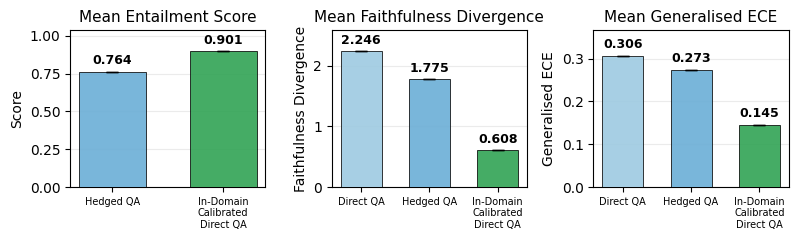

In [12]:
import matplotlib.pyplot as plt

# Values taken from the summary above
entailment_scores = {
    "Hedged QA": 0.764,
    "In-Domain\nCalibrated\nDirect QA": 0.901,
}

faithfulness_divergence = {
    "Direct QA": 2.246357953298256,
    "Hedged QA": 1.7749233048565647,
    "In-Domain\nCalibrated\nDirect QA": 0.6084209145267016,
}

generalised_ece = {
    "Direct QA": 0.30617605135981385,
    "Hedged QA": 0.272770214125857,
    "In-Domain\nCalibrated\nDirect QA": 0.14461845459660483,
}

fig, axes = plt.subplots(1, 3, figsize=(8, 2.5))

def annotate_bars(ax, bars, decimals=3):
    heights = [bar.get_height() for bar in bars]
    y_max = max(heights) if heights else 0
    y_offset = max(y_max * 0.03, 0.012)

    # Increase y-axis headroom so value labels stay within the subplot.
    current_bottom, current_top = ax.get_ylim()
    target_top = y_max + y_offset * 5.0
    if target_top > current_top:
        ax.set_ylim(current_bottom, target_top)

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + y_offset,
            f"{h:.{decimals}f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            clip_on=True,
        )

# LEFT: Mean entailment score (Hedged QA vs In-Domain Calibrated Direct QA)
bars0 = axes[0].bar(
    list(entailment_scores.keys()),
    list(entailment_scores.values()),
    color=["#6BAED6", "#31A354"],
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    width=0.6,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0],
)
axes[0].set_title("Mean Entailment Score", fontsize=11)
axes[0].set_ylabel("Score", fontsize=10)
axes[0].grid(axis="y", alpha=0.25, zorder=0)
axes[0].tick_params(axis="x", labelsize=7)
annotate_bars(axes[0], bars0, decimals=3)

# MIDDLE: Mean faithfulness divergence (three QAs)
bars1 = axes[1].bar(
    list(faithfulness_divergence.keys()),
    list(faithfulness_divergence.values()),
    color=["#9ECAE1", "#6BAED6", "#31A354"],
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    width=0.6,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0, 0.0],
)
axes[1].set_title("Mean Faithfulness Divergence", fontsize=11)
axes[1].set_ylabel("Faithfulness Divergence", fontsize=10)
axes[1].grid(axis="y", alpha=0.25, zorder=0)
axes[1].tick_params(axis="x", labelsize=7)
annotate_bars(axes[1], bars1, decimals=3)

# RIGHT: Mean generalised ECE (three QAs)
bars2 = axes[2].bar(
    list(generalised_ece.keys()),
    list(generalised_ece.values()),
    color=["#9ECAE1", "#6BAED6", "#31A354"],
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    width=0.6,
    zorder=3,
    capsize=4,
    yerr=[0.0, 0.0, 0.0],
)
axes[2].set_title("Mean Generalised ECE", fontsize=11)
axes[2].set_ylabel("Generalised ECE", fontsize=10)
axes[2].grid(axis="y", alpha=0.25, zorder=0)
axes[2].tick_params(axis="x", labelsize=7)
annotate_bars(axes[2], bars2, decimals=3)

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_ha("center")

fig.tight_layout()
plt.savefig("pipeline_vs_hedged_qa_baseline_calibration.pdf", dpi=300, bbox_inches="tight")